In [1]:
import funcs
import importlib

# Prépartion du dataset

In [2]:
path_data = 'data/source/images/'
path_data_save = 'data/cleaned/images/'
infos = funcs.get_filenames_labels_and_count(path_data)
funcs.display_n_images_per_class(infos)

,Maltese dog,Afghan hound,Scottish deerhound,Pomeranian,Samoyed,Bernese mountain dog,Irish wolfhound,Shih-Tzu,Great Pyrenees,Leonberg,...,affenpinscher,kuvasz,Eskimo dog,groenendael,malinois,Border collie,Doberman,Welsh springer spaniel,Pekinese,redbone
Nombre d'images,252,239,232,219,218,218,218,214,213,210,...,150,150,150,150,150,150,150,150,149,148


Nombre de classes: 120
Nombre total d'images: 20580
Nombre de classes conservées: 10
Nombre total d'images: 2233


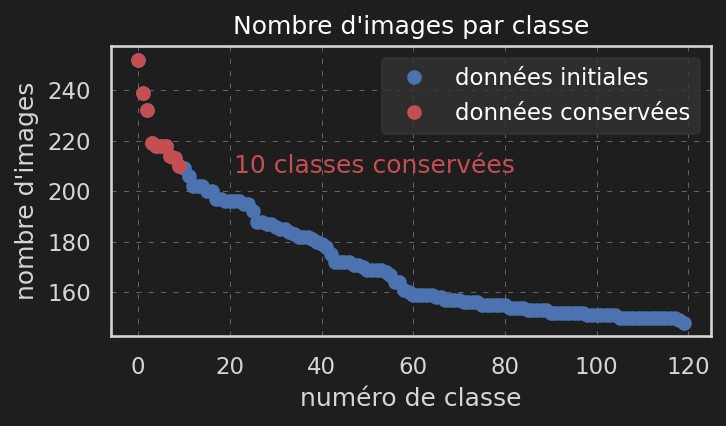

In [3]:
n_kept_classes = 10
funcs.plot_classes(infos, n_kept_classes)

In [4]:
funcs.get_kept_classes_and_folders(infos, path_data, n_kept_classes)
display(infos['df kept classes'])

,folder,n images
Maltese dog,n02085936-Maltese_dog,252
Afghan hound,n02088094-Afghan_hound,239
Scottish deerhound,n02092002-Scottish_deerhound,232
Pomeranian,n02112018-Pomeranian,219
Samoyed,n02111889-Samoyed,218
Bernese mountain dog,n02107683-Bernese_mountain_dog,218
Irish wolfhound,n02090721-Irish_wolfhound,218
Shih-Tzu,n02086240-Shih-Tzu,214
Great Pyrenees,n02111500-Great_Pyrenees,213
Leonberg,n02111129-Leonberg,210


In [5]:
funcs.read_image_shapes(path_data, infos)

Nombre d'images en noir et blanc 0


Nombre d'images: 2233
Nombre de largeurs différentes: 225
Nombre de hauteurs différentes: 283
i,j max: 140 190


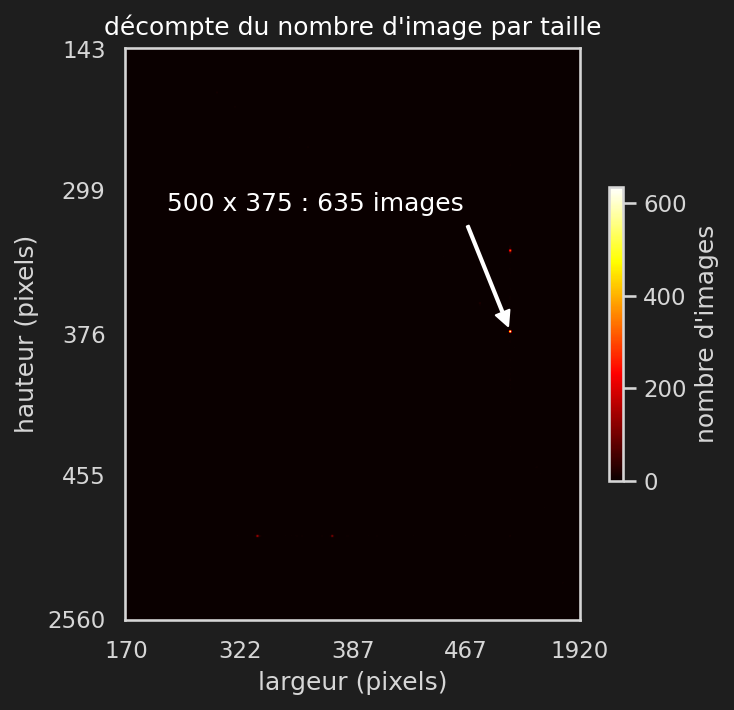

In [6]:
importlib.reload(funcs)
funcs.plot_image_shapes(infos)

In [7]:
target_shape = 224, 224
funcs.load_resize_crop_images(infos, path_data, path_data_save, target_shape)

/home/thomas/.local/lib/python3.11/site-packages/torchvision/transforms/functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


100%   


In [8]:
importlib.reload(funcs)
funcs.create_annotations_files(infos, path_data_save)

,folder,n images
Maltese dog,n02085936-Maltese_dog,252
Afghan hound,n02088094-Afghan_hound,239
Scottish deerhound,n02092002-Scottish_deerhound,232
Pomeranian,n02112018-Pomeranian,219
Samoyed,n02111889-Samoyed,218
Bernese mountain dog,n02107683-Bernese_mountain_dog,218
Irish wolfhound,n02090721-Irish_wolfhound,218
Shih-Tzu,n02086240-Shih-Tzu,214
Great Pyrenees,n02111500-Great_Pyrenees,213
Leonberg,n02111129-Leonberg,210


train dataset: (1783, 2)
test dataset: (450, 2)
Nombre total d'images: 2233


,filename,label
1738,Leonberg/n02111129_77.pt,9
886,Samoyed/n02111889_7002.pt,4
783,Samoyed/n02111889_4484.pt,4
1652,Leonberg/n02111129_545.pt,9
1465,Great_Pyrenees/n02111500_5057.pt,8
1325,Shih-Tzu/n02086240_3094.pt,7
1656,Leonberg/n02111129_4958.pt,9
858,Samoyed/n02111889_6249.pt,4
1200,Irish_wolfhound/n02090721_2945.pt,6
1251,Irish_wolfhound/n02090721_1774.pt,6


,filename,label
83,Afghan_hound/n02088094_3059.pt,1
217,Samoyed/n02111889_2820.pt,4
64,Afghan_hound/n02088094_1430.pt,1
71,Afghan_hound/n02088094_8631.pt,1
375,Great_Pyrenees/n02111500_1718.pt,8
20,Maltese_dog/n02085936_8507.pt,0
243,Bernese_mountain_dog/n02107683_357.pt,5
303,Irish_wolfhound/n02090721_4353.pt,6
201,Samoyed/n02111889_3221.pt,4
251,Bernese_mountain_dog/n02107683_4941.pt,5


Nombre de classes dans le dataset: 10
Nombre de classes dans le dataset: 10
image type: <class 'torch.Tensor'> tensor(255, device='cuda:0', dtype=torch.uint8)
label: tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]) argmax: 0


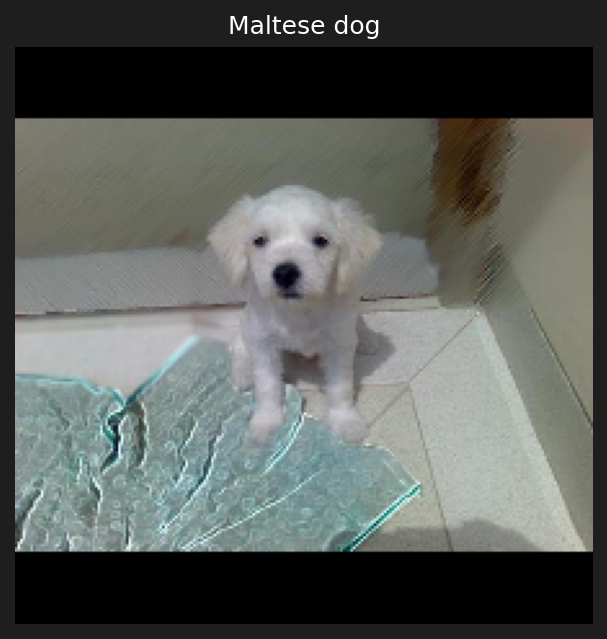

In [9]:
importlib.reload(funcs)
    
# one hot encoding transformer
train_data = funcs.CustomImageDataset('train', path_data_save)
test_data = funcs.CustomImageDataset('test', path_data_save)

funcs.test_class_dataset(train_data)

In [10]:
train_dataloader = DataLoader(train_data, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=True)

NameError: name 'DataLoader' is not defined

# Modélisation

In [ ]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")
if device == 'cuda':
    print(torch.cuda.get_device_name(torch.cuda.current_device()))

Using cuda device
NVIDIA GeForce RTX 3070 Laptop GPU


In [ ]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model = NeuralNetwork().to(device)
print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


In [ ]:
X = torch.rand(1, 28, 28, device=device)
logits = model(X)
pred_probab = nn.Softmax(dim=1)(logits)
y_pred = pred_probab.argmax(1)
print(f"Predicted class: {y_pred}")

In [ ]:
print(f"Model structure: {model}\n\n")

for name, param in model.named_parameters():
    print(f"Layer: {name} | Size: {param.size()} | Values : {param[:2]} \n")